<a href="https://colab.research.google.com/github/Thommartial/llm-unlearning-experiments/blob/main/notebooks/colab_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Unlearning Privacy Experiments — Colab (free T4)

**Before running:** Runtime ▸ Change runtime type ▸ Hardware accelerator = **T4 GPU**.
Then run the cells top to bottom. Colab already includes a CUDA build of PyTorch,
so we install everything *except* torch.


## 1. Confirm the GPU


In [1]:
!nvidia-smi


Fri May 29 20:23:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the repository


In [2]:
!git clone https://github.com/Thommartial/llm-unlearning-experiments.git
%cd llm-unlearning-experiments


Cloning into 'llm-unlearning-experiments'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 39 (delta 0), reused 39 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 19.17 KiB | 9.59 MiB/s, done.
/content/llm-unlearning-experiments


## 3. Install dependencies (torch is already provided by Colab)


In [3]:
!pip install -q -r requirements.txt
!pip install -q -e .
!python scripts/verify_gpu.py


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for unlearning (pyproject.toml) ... done
torch 2.11.0+cu128
CUDA available: True
device: Tesla T4 (14.6 GiB VRAM)


## 4. Offline sanity check (seconds)


In [4]:
!python scripts/run_experiment.py --config configs/smoke_synthetic.yaml --run


[plan] experiment 'smoke_synthetic' (seed=42)
[plan] model=tiny  data=synthetic  forget_fraction=0.25
[plan] unlearn=gradient_ascent  attack=loss_threshold
[plan] resolved config -> results/smoke_synthetic/config.resolved.json
[run] device=cpu
[run] splits: forget=30 retain=90 holdout=40
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
[run] pre-unlearning MIA AUC = 0.732
[run] post-unlearning MIA AUC = 0.302
[run] metrics -> results/smoke_synthetic/metrics.json


## 5. Real run: gpt2-medium + TOFU (a few minutes on a T4)
TOFU is a public dataset, so no Hugging Face login is needed for this config.


In [5]:
!python scripts/run_experiment.py --config configs/tofu_colab.yaml --run


[plan] experiment 'tofu_colab_gpt2med' (seed=42)
[plan] model=gpt2-medium  data=tofu  forget_fraction=0.1
[plan] unlearn=npo  attack=min_k_prob
[plan] resolved config -> results/tofu_colab_gpt2med/config.resolved.json
[run] device=cuda
config.json: 100% 718/718 [00:00<00:00, 3.48MB/s]
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 135kB/s]
vocab.json: 100% 1.04M/1.04M [00:00<00:00, 2.33MB/s]
merges.txt: 100% 456k/456k [00:00<00:00, 1.98MB/s]
tokenizer.json: 100% 1.36M/1.36M [00:00<00:00, 1.68MB/s]
model.safetensors: 100% 1.52G/1.52G [00:18<00:00, 82.6MB/s]
Loading weights: 100% 292/292 [00:00<00:00, 1089.97it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
generation_config.json: 100% 124/124 [00:00<

## 6. Inspect results


In [6]:
import json
m = json.load(open('results/tofu_colab_gpt2med/metrics.json'))
print(json.dumps(m, indent=2))


{
  "experiment": "tofu_colab_gpt2med",
  "method": "npo",
  "attack": "min_k_prob",
  "pre_unlearning": {
    "mia_auc": 0.57876953125,
    "mia_advantage": 0.07876953124999997,
    "mia_auc_typical": 0.57876953125,
    "mia_advantage_typical": 0.07876953124999997
  },
  "post_unlearning": {
    "mia_auc": 0.48605078125,
    "mia_advantage": 0.013949218749999992,
    "mia_auc_typical": 0.48605078125,
    "mia_advantage_typical": 0.013949218749999992
  },
  "forget_loss_post": 74.42926683425904,
  "retain_loss_post": 74.3555189344618
}


rendered results/tofu_colab_gpt2med/figure_mia.pdf


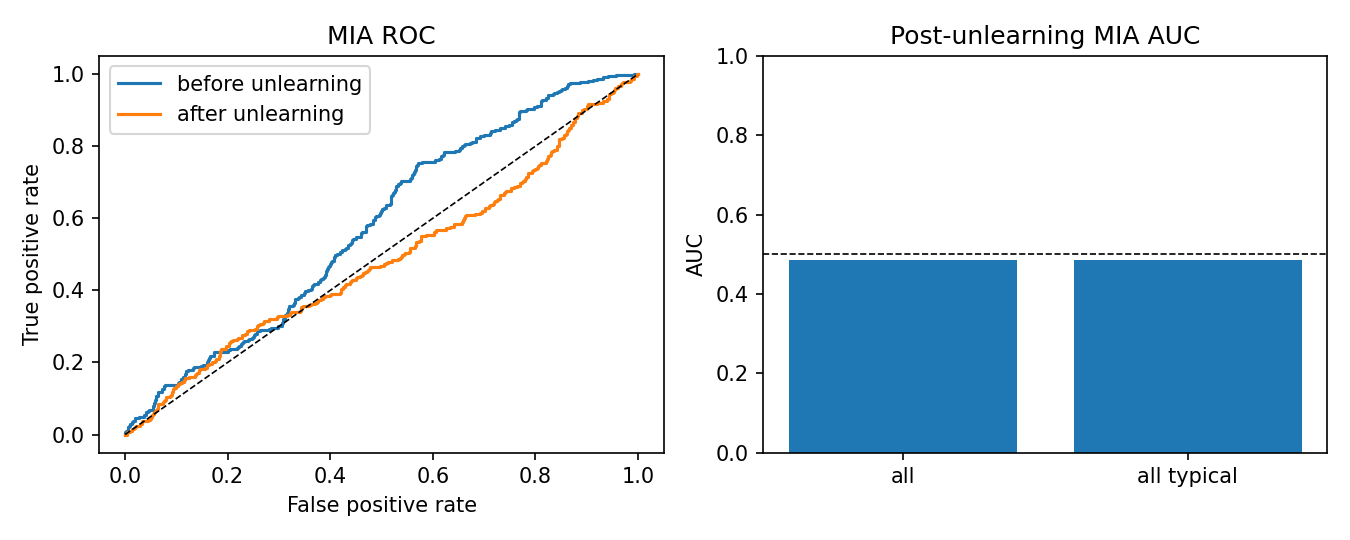

In [8]:
!python -m unlearning.plotting --results results --name tofu_colab_gpt2med
from IPython.display import Image
Image('results/tofu_colab_gpt2med/figure_mia.png')

## 7. Save your results
Download the run folder so you keep metrics + figures after the session ends.


In [9]:
!zip -r tofu_colab_results.zip results/tofu_colab_gpt2med
from google.colab import files
files.download('tofu_colab_results.zip')


  adding: results/tofu_colab_gpt2med/ (stored 0%)
  adding: results/tofu_colab_gpt2med/scores.npz (deflated 22%)
  adding: results/tofu_colab_gpt2med/metrics.json (deflated 58%)
  adding: results/tofu_colab_gpt2med/figure_mia.png (deflated 12%)
  adding: results/tofu_colab_gpt2med/config.resolved.json (deflated 51%)
  adding: results/tofu_colab_gpt2med/figure_mia.pdf (deflated 24%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Notes
- Free Colab disconnects after ~90 min idle (and ~12 h max). Keep the tab active.
- If `nvidia-smi` shows no GPU, re-check the runtime type.
- To try a gated model (e.g. Llama-3.2-1B) add `!huggingface-cli login`, accept the
  model licence on its HF page, and implement LoRA first (full fine-tune of 1B is tight).
